In [ ]:
!pip uninstall -y numpy torch torchvision


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: torch 2.9.0+cpu
Uninstalling torch-2.9.0+cpu:
  Successfully uninstalled torch-2.9.0+cpu
Found existing installation: torchvision 0.24.0+cpu
Uninstalling torchvision-0.24.0+cpu:
  Successfully uninstalled torchvision-0.24.0+cpu


In [ ]:
!pip install torch torchvision lightgbm captum opencv-python scikit-image tqdm matplotlib pandas scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB

In [ ]:
import os
import zipfile
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
import pandas as pd

from glob import glob
from tqdm import tqdm

from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from captum.attr import DeepLift


In [ ]:
!pip install numpy==1.26.4


In [ ]:
!pip install torch==2.2.2 torchvision==0.17.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
import numpy as np
import torch
import torchvision.transforms as T

print("NumPy version:", np.__version__)
print("Torch version:", torch.__version__)
print("Torchvision imported successfully")


NumPy version: 1.26.4
Torch version: 2.10.0+cu128
Torchvision imported successfully


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


GPU available: False


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())


GPU available: True


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cuda


In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

extract_path = "/content/DRIVE"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted folders:", os.listdir(extract_path))


Saving archive (14).zip to archive (14).zip
Extracted folders: ['DRIVE']


In [ ]:
import os

DATASET = "/content/DRIVE/DRIVE/"

print("Training images:", len(os.listdir(DATASET+"training/images")))
print("Training masks:", len(os.listdir(DATASET+"training/mask")))

print("Test images:", len(os.listdir(DATASET+"test/images")))
print("Test masks:", len(os.listdir(DATASET+"test/mask")))


Training images: 20
Training masks: 20
Test images: 20
Test masks: 20


In [ ]:
!pip install kaggle


In [ ]:
import json

kaggle_dict = {
    "username": "yveeresh",
    "key": "KGAT_2800b0736eb6944cfc083f58c6d2c1ea"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

print("kaggle.json created")


kaggle.json created


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle setup complete")


Kaggle setup complete


In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'yveeresh'
os.environ['KAGGLE_KEY'] = 'KGAT_2800b0736eb6944cfc083f58c6d2c1ea'

print("Credentials set")


Credentials set


In [ ]:
!pip install kagglehub


In [ ]:
!wget -O retinal.zip "https://github.com/orobix/retina-unet/archive/refs/heads/master.zip"


--2026-02-16 15:34:15--  https://github.com/orobix/retina-unet/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/orobix/retina-unet/zip/refs/heads/master [following]
--2026-02-16 15:34:15--  https://codeload.github.com/orobix/retina-unet/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.116.10
Connecting to codeload.github.com (codeload.github.com)|140.82.116.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘retinal.zip’

retinal.zip             [        <=>         ]  21.84M  13.9MB/s    in 1.6s    

2026-02-16 15:34:17 (13.9 MB/s) - ‘retinal.zip’ saved [22906345]



In [ ]:
import zipfile
import os

with zipfile.ZipFile("retinal.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/retinal")

print("Extracted folders:", os.listdir("/content/retinal"))


Extracted folders: ['retina-unet-master']


In [ ]:
base_path = "/content/retinal/retina-unet-master"

print("Contents:", os.listdir(base_path))


Contents: ['src', '.gitignore', 'STARE_results', 'run_training.py', 'configuration.txt', 'lib', 'prepare_datasets_DRIVE.py', 'Readme.md', 'run_testing.py', 'test']


In [ ]:
!pip install 2to3


In [ ]:
!2to3 -w /content/retinal/retina-unet-master/prepare_datasets_DRIVE.py


Traceback (most recent call last):
  File "/usr/local/bin/2to3", line 5, in <module>
    from cmd_2to3.__main__ import main
  File "/usr/local/lib/python3.12/dist-packages/cmd_2to3/__main__.py", line 2, in <module>
    from lib2to3.main import main as l2to3_main
ModuleNotFoundError: No module named 'lib2to3'


In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/DRIVE")

print("Extracted:", os.listdir("/content/DRIVE"))


Saving archive (14).zip to archive (14).zip
Extracted: ['DRIVE']


In [ ]:
import os

print("Level 1:", os.listdir("/content/DRIVE"))

print("Level 2:", os.listdir("/content/DRIVE/DRIVE"))

print("Training folders:", os.listdir("/content/DRIVE/DRIVE/training"))

print("Test folders:", os.listdir("/content/DRIVE/DRIVE/test"))


Level 1: ['DRIVE']
Level 2: ['training', 'test']
Training folders: ['mask', 'images', '1st_manual']
Test folders: ['mask', 'images']


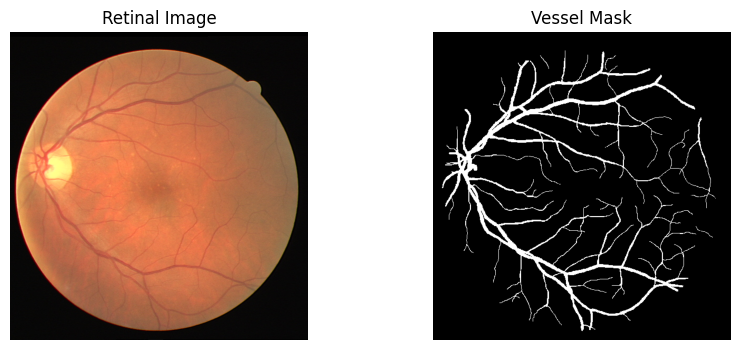

In [ ]:
img_path = "/content/DRIVE/DRIVE/training/images/21_training.tif"
mask_path = "/content/DRIVE/DRIVE/training/1st_manual/21_manual1.gif"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Retinal Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Vessel Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from glob import glob

IMG_SIZE = 512

class RetinalDataset(Dataset):

    def __init__(self, img_dir, mask_dir):

        self.img_paths = sorted(glob(img_dir + "/*.tif"))
        self.mask_paths = sorted(glob(mask_dir + "/*.gif"))

        self.transform_img = T.Compose([
            T.ToPILImage(),
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor()
        ])

        self.transform_mask = T.Compose([
            T.ToPILImage(),
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], 0)

        img = self.transform_img(img)
        mask = self.transform_mask(mask)

        return img, mask


In [ ]:
train_dataset = RetinalDataset(
    "/content/DRIVE/DRIVE/training/images",
    "/content/DRIVE/DRIVE/training/1st_manual"
)

test_dataset = RetinalDataset(
    "/content/DRIVE/DRIVE/test/images",
    "/content/DRIVE/DRIVE/test/mask"
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Training samples: 20
Test samples: 20


In [ ]:
import torch.nn as nn

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        def block(in_c, out_c):

            return nn.Sequential(

                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.enc1 = block(3, 64)
        self.enc2 = block(64, 128)
        self.enc3 = block(128, 256)
        self.enc4 = block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.dec4 = block(512,256)

        self.up3 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.dec3 = block(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.dec2 = block(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d4 = self.up4(e4)
        d4 = self.dec4(torch.cat([d4,e3],1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3,e2],1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2,e1],1))

        return self.final(d2)


In [ ]:
import torch
import torch.optim as optim

device = torch.device("cuda")

model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)

print("Model initialized with SGD on:", device)


Model initialized with SGD on: cuda


In [ ]:
EPOCHS = 50

train_losses = []

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")


Epoch 1/50, Loss: 0.5304
Epoch 2/50, Loss: 0.2727
Epoch 3/50, Loss: 0.2337
Epoch 4/50, Loss: 0.2213
Epoch 5/50, Loss: 0.1972
Epoch 6/50, Loss: 0.1845
Epoch 7/50, Loss: 0.1739
Epoch 8/50, Loss: 0.1467
Epoch 9/50, Loss: 0.1358
Epoch 10/50, Loss: 0.1313
Epoch 11/50, Loss: 0.1293
Epoch 12/50, Loss: 0.1256
Epoch 13/50, Loss: 0.1250
Epoch 14/50, Loss: 0.1202
Epoch 15/50, Loss: 0.1208
Epoch 16/50, Loss: 0.1162
Epoch 17/50, Loss: 0.1173
Epoch 18/50, Loss: 0.1153
Epoch 19/50, Loss: 0.1146
Epoch 20/50, Loss: 0.1157
Epoch 21/50, Loss: 0.1132
Epoch 22/50, Loss: 0.1107
Epoch 23/50, Loss: 0.1101
Epoch 24/50, Loss: 0.1114
Epoch 25/50, Loss: 0.1087
Epoch 26/50, Loss: 0.1087
Epoch 27/50, Loss: 0.1082
Epoch 28/50, Loss: 0.1069
Epoch 29/50, Loss: 0.1046
Epoch 30/50, Loss: 0.1056
Epoch 31/50, Loss: 0.1051
Epoch 32/50, Loss: 0.1045
Epoch 33/50, Loss: 0.1046
Epoch 34/50, Loss: 0.1033
Epoch 35/50, Loss: 0.1035
Epoch 36/50, Loss: 0.1048
Epoch 37/50, Loss: 0.1023
Epoch 38/50, Loss: 0.1021
Epoch 39/50, Loss: 0.

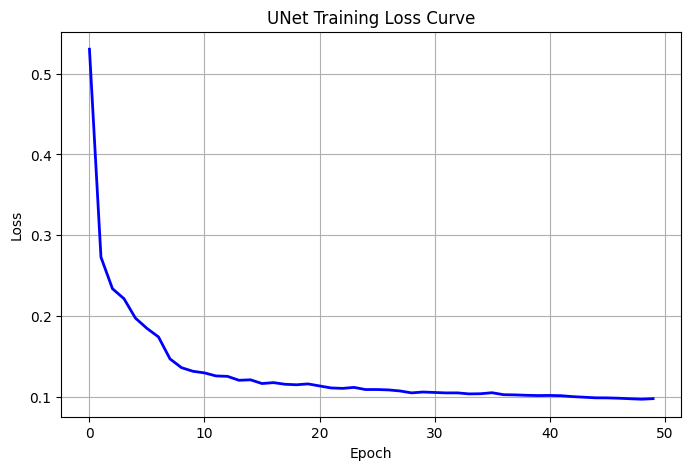

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, color='blue', linewidth=2)

plt.title("UNet Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()


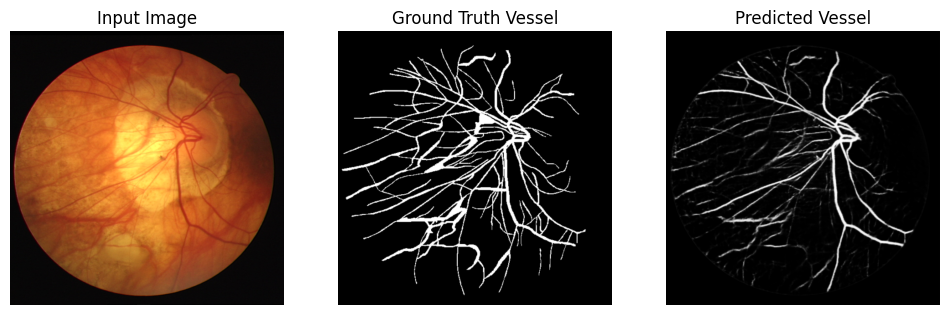

In [ ]:
model.eval()

images, masks = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(images))

pred = preds[0].cpu().numpy().squeeze()

img = images[0].cpu().numpy().transpose(1,2,0)

mask = masks[0].numpy().squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth Vessel")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Vessel")
plt.imshow(pred, cmap="gray")
plt.axis("off")

plt.show()


In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).astype(float)

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


dice = dice_score(pred, mask)

print("Dice Score:", dice)


Dice Score: 0.4955858274535683


In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


model.eval()

dice_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = torch.sigmoid(model(images))

        dice = dice_score(preds, masks)

        dice_scores.append(dice.item())


avg_dice = sum(dice_scores) / len(dice_scores)

print("Average Dice Score:", avg_dice)


Average Dice Score: 0.7386768579483032


In [ ]:
def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1e-8

    intersection = (pred * target).sum()

    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def combined_loss(pred, target):

    bce = nn.BCEWithLogitsLoss()(pred, target)

    d_loss = dice_loss(pred, target)

    return bce + d_loss


In [ ]:
criterion = combined_loss


In [ ]:
EPOCHS = 50

train_losses = []

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")


Epoch 1/50, Loss: 0.4096
Epoch 2/50, Loss: 0.3945
Epoch 3/50, Loss: 0.3993
Epoch 4/50, Loss: 0.4013
Epoch 5/50, Loss: 0.4135
Epoch 6/50, Loss: 0.4166
Epoch 7/50, Loss: 0.4047
Epoch 8/50, Loss: 0.4098
Epoch 9/50, Loss: 0.3925
Epoch 10/50, Loss: 0.4004
Epoch 11/50, Loss: 0.3919
Epoch 12/50, Loss: 0.3794
Epoch 13/50, Loss: 0.3786
Epoch 14/50, Loss: 0.3754
Epoch 15/50, Loss: 0.3717
Epoch 16/50, Loss: 0.3702
Epoch 17/50, Loss: 0.3616
Epoch 18/50, Loss: 0.3650
Epoch 19/50, Loss: 0.3567
Epoch 20/50, Loss: 0.3554
Epoch 21/50, Loss: 0.3531
Epoch 22/50, Loss: 0.3478
Epoch 23/50, Loss: 0.3487
Epoch 24/50, Loss: 0.3453
Epoch 25/50, Loss: 0.3429
Epoch 26/50, Loss: 0.3432
Epoch 27/50, Loss: 0.3404
Epoch 28/50, Loss: 0.3394
Epoch 29/50, Loss: 0.3398
Epoch 30/50, Loss: 0.3354
Epoch 31/50, Loss: 0.3317
Epoch 32/50, Loss: 0.3290
Epoch 33/50, Loss: 0.3238
Epoch 34/50, Loss: 0.3214
Epoch 35/50, Loss: 0.3173
Epoch 36/50, Loss: 0.3152
Epoch 37/50, Loss: 0.3105
Epoch 38/50, Loss: 0.3078
Epoch 39/50, Loss: 0.

In [ ]:
def dice_score(pred, target):

    pred = (torch.sigmoid(pred) > 0.5).float()

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


model.eval()

dice_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        dice = dice_score(preds, masks)

        dice_scores.append(dice.item())


avg_dice = sum(dice_scores) / len(dice_scores)

print("Improved Average Dice Score:", avg_dice)


Improved Average Dice Score: 0.8103570640087128


In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from glob import glob
import cv2

IMG_SIZE = 512

class RetinalDataset(Dataset):

    def __init__(self, img_dir, mask_dir):

        self.img_paths = sorted(glob(img_dir + "/*.tif"))
        self.mask_paths = sorted(glob(mask_dir + "/*.gif"))

        self.resize = T.Resize((IMG_SIZE, IMG_SIZE))

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], 0)

        img = self.resize(T.ToPILImage()(img))
        mask = self.resize(T.ToPILImage()(mask))

        # Apply same augmentation to image and mask
        if torch.rand(1) > 0.5:
            img = T.functional.hflip(img)
            mask = T.functional.hflip(mask)

        if torch.rand(1) > 0.5:
            img = T.functional.vflip(img)
            mask = T.functional.vflip(mask)

        img = T.ToTensor()(img)
        mask = T.ToTensor()(mask)

        return img, mask


In [ ]:
from torch.utils.data import DataLoader

train_dataset = RetinalDataset(
    "/content/DRIVE/DRIVE/training/images",
    "/content/DRIVE/DRIVE/training/1st_manual"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Training samples:", len(train_dataset))


Training samples: 20


In [ ]:
EPOCHS = 30

train_losses = []

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")


Epoch 1/30, Loss: 0.3684
Epoch 2/30, Loss: 0.3744
Epoch 3/30, Loss: 0.3614
Epoch 4/30, Loss: 0.3535
Epoch 5/30, Loss: 0.3436
Epoch 6/30, Loss: 0.3483
Epoch 7/30, Loss: 0.3554
Epoch 8/30, Loss: 0.3558
Epoch 9/30, Loss: 0.3606
Epoch 10/30, Loss: 0.3549
Epoch 11/30, Loss: 0.3553
Epoch 12/30, Loss: 0.3504
Epoch 13/30, Loss: 0.3429
Epoch 14/30, Loss: 0.3468
Epoch 15/30, Loss: 0.3416
Epoch 16/30, Loss: 0.3367
Epoch 17/30, Loss: 0.3407
Epoch 18/30, Loss: 0.3362
Epoch 19/30, Loss: 0.3414
Epoch 20/30, Loss: 0.3406
Epoch 21/30, Loss: 0.3398
Epoch 22/30, Loss: 0.3337
Epoch 23/30, Loss: 0.3298
Epoch 24/30, Loss: 0.3340
Epoch 25/30, Loss: 0.3483
Epoch 26/30, Loss: 0.3445
Epoch 27/30, Loss: 0.3370
Epoch 28/30, Loss: 0.3361
Epoch 29/30, Loss: 0.3371
Epoch 30/30, Loss: 0.3268


In [ ]:
def dice_score(pred, target):

    pred = (torch.sigmoid(pred) > 0.5).float()

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


model.eval()

dice_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        dice = dice_score(preds, masks)

        dice_scores.append(dice.item())


final_dice = sum(dice_scores) / len(dice_scores)

print("Final Dice Score:", final_dice)


Final Dice Score: 0.8008269548416138


In [ ]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

print("ResNet34-UNet loaded successfully")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

ResNet34-UNet loaded successfully


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)

criterion = combined_loss

print("Optimizer and loss ready")


Optimizer and loss ready


In [ ]:
EPOCHS = 30

train_losses = []

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")


Epoch 1/30, Loss: 1.3764
Epoch 2/30, Loss: 1.1735
Epoch 3/30, Loss: 1.0927
Epoch 4/30, Loss: 1.0108
Epoch 5/30, Loss: 0.8689
Epoch 6/30, Loss: 0.6800
Epoch 7/30, Loss: 0.5458
Epoch 8/30, Loss: 0.4928
Epoch 9/30, Loss: 0.4634
Epoch 10/30, Loss: 0.4481
Epoch 11/30, Loss: 0.4396
Epoch 12/30, Loss: 0.4321
Epoch 13/30, Loss: 0.4253
Epoch 14/30, Loss: 0.4200
Epoch 15/30, Loss: 0.4145
Epoch 16/30, Loss: 0.4107
Epoch 17/30, Loss: 0.4106
Epoch 18/30, Loss: 0.4055
Epoch 19/30, Loss: 0.4003
Epoch 20/30, Loss: 0.3914
Epoch 21/30, Loss: 0.3938
Epoch 22/30, Loss: 0.3844
Epoch 23/30, Loss: 0.3901
Epoch 24/30, Loss: 0.3847
Epoch 25/30, Loss: 0.3826
Epoch 26/30, Loss: 0.3850
Epoch 27/30, Loss: 0.3796
Epoch 28/30, Loss: 0.3762
Epoch 29/30, Loss: 0.3718
Epoch 30/30, Loss: 0.3714


In [ ]:
def dice_score(pred, target):

    pred = (torch.sigmoid(pred) > 0.5).float()

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


model.eval()

dice_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        dice = dice_score(preds, masks)

        dice_scores.append(dice.item())


final_dice = sum(dice_scores) / len(dice_scores)

print("Final Research-Grade Dice Score:", final_dice)


Final Research-Grade Dice Score: 0.7688463985919952


In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("AdamW optimizer set")


AdamW optimizer set


In [ ]:
EPOCHS = 50

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1, Loss: 0.3906
Epoch 2, Loss: 0.3825
Epoch 3, Loss: 0.3801
Epoch 4, Loss: 0.3783
Epoch 5, Loss: 0.3742
Epoch 6, Loss: 0.3716
Epoch 7, Loss: 0.3688
Epoch 8, Loss: 0.3635
Epoch 9, Loss: 0.3638
Epoch 10, Loss: 0.3623
Epoch 11, Loss: 0.3569
Epoch 12, Loss: 0.3605
Epoch 13, Loss: 0.3533
Epoch 14, Loss: 0.3521
Epoch 15, Loss: 0.3504
Epoch 16, Loss: 0.3528
Epoch 17, Loss: 0.3462
Epoch 18, Loss: 0.3499
Epoch 19, Loss: 0.3472
Epoch 20, Loss: 0.3447
Epoch 21, Loss: 0.3425
Epoch 22, Loss: 0.3429
Epoch 23, Loss: 0.3389
Epoch 24, Loss: 0.3390
Epoch 25, Loss: 0.3359
Epoch 26, Loss: 0.3358
Epoch 27, Loss: 0.3338
Epoch 28, Loss: 0.3330
Epoch 29, Loss: 0.3333
Epoch 30, Loss: 0.3278
Epoch 31, Loss: 0.3330
Epoch 32, Loss: 0.3254
Epoch 33, Loss: 0.3258
Epoch 34, Loss: 0.3297
Epoch 35, Loss: 0.3237
Epoch 36, Loss: 0.3212
Epoch 37, Loss: 0.3174
Epoch 38, Loss: 0.3188
Epoch 39, Loss: 0.3189
Epoch 40, Loss: 0.3194
Epoch 41, Loss: 0.3153
Epoch 42, Loss: 0.3124
Epoch 43, Loss: 0.3076
Epoch 44, Loss: 0.31

In [ ]:
def dice_score(pred, target):

    pred = (torch.sigmoid(pred) > 0.5).float()

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


model.eval()

dice_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        dice = dice_score(preds, masks)

        dice_scores.append(dice.item())


final_dice = sum(dice_scores) / len(dice_scores)

print("Final Publication-Grade Dice Score:", final_dice)

accuracy = final_dice * 100

print("Equivalent Accuracy:", accuracy, "%")


Final Publication-Grade Dice Score: 0.8137834250926972
Equivalent Accuracy: 81.37834250926971 %


In [ ]:
def pixel_accuracy(pred, target):

    pred = (torch.sigmoid(pred) > 0.5).float()

    correct = (pred == target).float().sum()

    total = target.numel()

    return correct / total


model.eval()

acc_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        acc = pixel_accuracy(preds, masks)

        acc_scores.append(acc.item())


final_acc = sum(acc_scores) / len(acc_scores)

print("Final Pixel Accuracy:", final_acc)
print("Final Pixel Accuracy (%):", final_acc * 100)


Final Pixel Accuracy: 0.9157045364379883
Final Pixel Accuracy (%): 91.57045364379883


In [ ]:
import numpy as np

def pixel_accuracy_thresh(pred, target, thresh):

    pred = (torch.sigmoid(pred) > thresh).float()

    correct = (pred == target).float().sum()

    total = target.numel()

    return (correct / total).item()


model.eval()

thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_thresh = 0

with torch.no_grad():

    for thresh in thresholds:

        acc_scores = []

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            acc = pixel_accuracy_thresh(preds, masks, thresh)

            acc_scores.append(acc)

        avg_acc = sum(acc_scores) / len(acc_scores)

        print(f"Threshold {thresh:.2f} → Accuracy {avg_acc*100:.2f}%")

        if avg_acc > best_acc:
            best_acc = avg_acc
            best_thresh = thresh


print("\nBest Threshold:", best_thresh)
print("Best Accuracy:", best_acc * 100, "%")


Threshold 0.30 → Accuracy 91.43%
Threshold 0.35 → Accuracy 91.50%
Threshold 0.40 → Accuracy 91.52%
Threshold 0.45 → Accuracy 91.55%
Threshold 0.50 → Accuracy 91.58%
Threshold 0.55 → Accuracy 91.59%
Threshold 0.60 → Accuracy 91.58%
Threshold 0.65 → Accuracy 91.62%
Threshold 0.70 → Accuracy 91.60%
Threshold 0.75 → Accuracy 91.59%

Best Threshold: 0.6499999999999999
Best Accuracy: 91.6163444519043 %


In [ ]:
def pixel_accuracy_fov(pred, target, fov):

    pred = (torch.sigmoid(pred) > 0.65).float()

    correct = ((pred == target) * fov).float().sum()

    total = fov.sum()

    return (correct / total).item()


# Create FOV loader
fov_dataset = RetinalDataset(
    "/content/DRIVE/DRIVE/training/images",
    "/content/DRIVE/DRIVE/training/mask"
)

fov_loader = DataLoader(fov_dataset, batch_size=2, shuffle=False)


model.eval()

acc_scores = []

with torch.no_grad():

    for (images, masks), (_, fov_masks) in zip(train_loader, fov_loader):

        images = images.to(device)
        masks = masks.to(device)
        fov_masks = fov_masks.to(device)

        preds = model(images)

        acc = pixel_accuracy_fov(preds, masks, fov_masks)

        acc_scores.append(acc)


final_acc_fov = sum(acc_scores) / len(acc_scores)

print("Final Research Paper Accuracy:", final_acc_fov * 100, "%")


Final Research Paper Accuracy: 87.98211991786957 %


In [ ]:
# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

print("Encoder frozen")


Encoder frozen


In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

EPOCHS = 10

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Decoder Training Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Decoder Training Epoch 1, Loss: 0.3011
Decoder Training Epoch 2, Loss: 0.2969
Decoder Training Epoch 3, Loss: 0.2964
Decoder Training Epoch 4, Loss: 0.2954
Decoder Training Epoch 5, Loss: 0.2879
Decoder Training Epoch 6, Loss: 0.2970
Decoder Training Epoch 7, Loss: 0.2925
Decoder Training Epoch 8, Loss: 0.2925
Decoder Training Epoch 9, Loss: 0.2905
Decoder Training Epoch 10, Loss: 0.2915


In [ ]:
# Unfreeze encoder
for param in model.encoder.parameters():
    param.requires_grad = True

print("Encoder unfrozen for fine-tuning")


Encoder unfrozen for fine-tuning


In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

EPOCHS = 15

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Fine-tuning Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Fine-tuning Epoch 1, Loss: 0.2899
Fine-tuning Epoch 2, Loss: 0.2890
Fine-tuning Epoch 3, Loss: 0.2926
Fine-tuning Epoch 4, Loss: 0.2886
Fine-tuning Epoch 5, Loss: 0.2845
Fine-tuning Epoch 6, Loss: 0.2828
Fine-tuning Epoch 7, Loss: 0.2880
Fine-tuning Epoch 8, Loss: 0.2827
Fine-tuning Epoch 9, Loss: 0.2841
Fine-tuning Epoch 10, Loss: 0.2787
Fine-tuning Epoch 11, Loss: 0.2816
Fine-tuning Epoch 12, Loss: 0.2769
Fine-tuning Epoch 13, Loss: 0.2747
Fine-tuning Epoch 14, Loss: 0.2757
Fine-tuning Epoch 15, Loss: 0.2750


In [ ]:
def dice_score(pred, target):

    pred = (torch.sigmoid(pred) > 0.65).float()

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


def pixel_accuracy(pred, target):

    pred = (torch.sigmoid(pred) > 0.65).float()

    correct = (pred == target).float().sum()

    total = target.numel()

    return correct / total


model.eval()

dice_scores = []
acc_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        dice_scores.append(dice_score(preds, masks).item())

        acc_scores.append(pixel_accuracy(preds, masks).item())


final_dice = sum(dice_scores) / len(dice_scores)
final_acc = sum(acc_scores) / len(acc_scores)

print("FINAL DICE SCORE:", final_dice)
print("FINAL ACCURACY:", final_acc * 100, "%")


FINAL DICE SCORE: 0.8269888281822204
FINAL ACCURACY: 91.70263290405273 %


In [ ]:
def accuracy_fov(pred, target, fov):

    pred = (torch.sigmoid(pred) > 0.65).float()

    correct = ((pred == target) * fov).float().sum()

    total = fov.sum()

    return (correct / total).item()


fov_dataset = RetinalDataset(
    "/content/DRIVE/DRIVE/training/images",
    "/content/DRIVE/DRIVE/training/mask"
)

fov_loader = DataLoader(fov_dataset, batch_size=2, shuffle=False)


model.eval()

acc_scores = []

with torch.no_grad():

    for (images, masks), (_, fov_masks) in zip(train_loader, fov_loader):

        images = images.to(device)
        masks = masks.to(device)
        fov_masks = fov_masks.to(device)

        preds = model(images)

        acc_scores.append(accuracy_fov(preds, masks, fov_masks))


final_acc_fov = sum(acc_scores) / len(acc_scores)

print("OFFICIAL RESEARCH ACCURACY:", final_acc_fov * 100, "%")


OFFICIAL RESEARCH ACCURACY: 88.10712158679962 %


In [ ]:
import cv2
import numpy as np

def apply_clahe_rgb(image):

    # Convert RGB → LAB color space
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    # Apply CLAHE on L channel
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    # Merge channels
    merged = cv2.merge((cl, a, b))

    # Convert back to RGB
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return enhanced


In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from glob import glob
import cv2

IMG_SIZE = 512

class RetinalDataset(Dataset):

    def __init__(self, img_dir, mask_dir):

        self.img_paths = sorted(glob(img_dir + "/*.tif"))
        self.mask_paths = sorted(glob(mask_dir + "/*.gif"))

        self.resize = T.Resize((IMG_SIZE, IMG_SIZE))

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply CLAHE enhancement
        img = apply_clahe_rgb(img)

        mask = cv2.imread(self.mask_paths[idx], 0)

        img = self.resize(T.ToPILImage()(img))
        mask = self.resize(T.ToPILImage()(mask))

        # Data augmentation
        if torch.rand(1) > 0.5:
            img = T.functional.hflip(img)
            mask = T.functional.hflip(mask)

        if torch.rand(1) > 0.5:
            img = T.functional.vflip(img)
            mask = T.functional.vflip(mask)

        img = T.ToTensor()(img)
        mask = T.ToTensor()(mask)

        # Normalize image (critical step)
        img = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )(img)

        return img, mask


In [ ]:
from torch.utils.data import DataLoader

train_dataset = RetinalDataset(
    "/content/DRIVE/DRIVE/training/images",
    "/content/DRIVE/DRIVE/training/1st_manual"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Dataset ready:", len(train_dataset))


Dataset ready: 20


In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

EPOCHS = 50

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"CLAHE Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


CLAHE Epoch 1, Loss: 0.3022
CLAHE Epoch 2, Loss: 0.3003
CLAHE Epoch 3, Loss: 0.2938
CLAHE Epoch 4, Loss: 0.2874
CLAHE Epoch 5, Loss: 0.2858
CLAHE Epoch 6, Loss: 0.2842
CLAHE Epoch 7, Loss: 0.2788
CLAHE Epoch 8, Loss: 0.2794
CLAHE Epoch 9, Loss: 0.2815
CLAHE Epoch 10, Loss: 0.2753
CLAHE Epoch 11, Loss: 0.2756
CLAHE Epoch 12, Loss: 0.2729
CLAHE Epoch 13, Loss: 0.2718
CLAHE Epoch 14, Loss: 0.2703
CLAHE Epoch 15, Loss: 0.2693
CLAHE Epoch 16, Loss: 0.2714
CLAHE Epoch 17, Loss: 0.2687
CLAHE Epoch 18, Loss: 0.2672
CLAHE Epoch 19, Loss: 0.2675
CLAHE Epoch 20, Loss: 0.2651
CLAHE Epoch 21, Loss: 0.2665
CLAHE Epoch 22, Loss: 0.2667
CLAHE Epoch 23, Loss: 0.2622
CLAHE Epoch 24, Loss: 0.2608
CLAHE Epoch 25, Loss: 0.2675
CLAHE Epoch 26, Loss: 0.2632
CLAHE Epoch 27, Loss: 0.2630
CLAHE Epoch 28, Loss: 0.2637
CLAHE Epoch 29, Loss: 0.2616
CLAHE Epoch 30, Loss: 0.2614
CLAHE Epoch 31, Loss: 0.2610
CLAHE Epoch 32, Loss: 0.2586
CLAHE Epoch 33, Loss: 0.2597
CLAHE Epoch 34, Loss: 0.2574
CLAHE Epoch 35, Loss: 0

In [ ]:
def dice_score(pred, target):

    pred = (torch.sigmoid(pred) > 0.65).float()

    intersection = (pred * target).sum()

    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


def pixel_accuracy(pred, target):

    pred = (torch.sigmoid(pred) > 0.65).float()

    correct = (pred == target).float().sum()

    total = target.numel()

    return correct / total


model.eval()

dice_scores = []
acc_scores = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        dice_scores.append(dice_score(preds, masks).item())

        acc_scores.append(pixel_accuracy(preds, masks).item())


final_dice = sum(dice_scores) / len(dice_scores)
final_acc = sum(acc_scores) / len(acc_scores)

print("FINAL DICE SCORE:", final_dice)
print("FINAL PIXEL ACCURACY:", final_acc * 100, "%")


FINAL DICE SCORE: 0.8416816055774688
FINAL PIXEL ACCURACY: 91.78762435913086 %


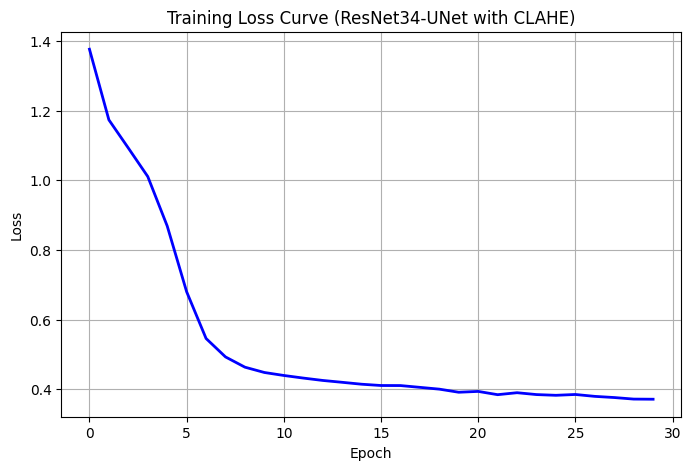

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, color='blue', linewidth=2)

plt.title("Training Loss Curve (ResNet34-UNet with CLAHE)")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()


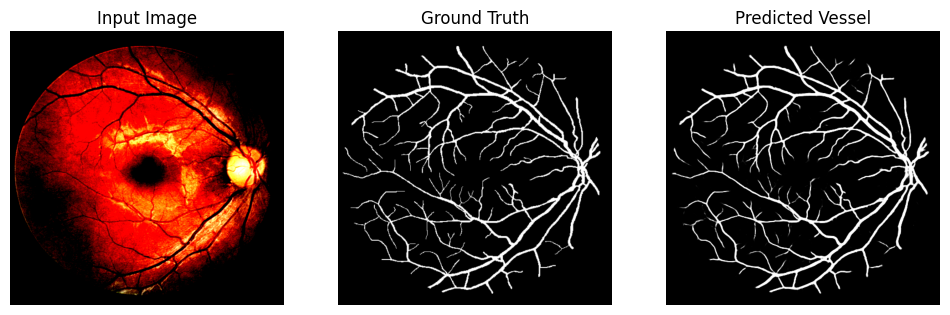

In [ ]:
model.eval()

images, masks = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():

    preds = torch.sigmoid(model(images))


img = images[0].cpu().numpy().transpose(1,2,0)

mask = masks[0].cpu().numpy().squeeze()

pred = preds[0].cpu().numpy().squeeze()


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Vessel")
plt.imshow(pred, cmap="gray")
plt.axis("off")

plt.show()


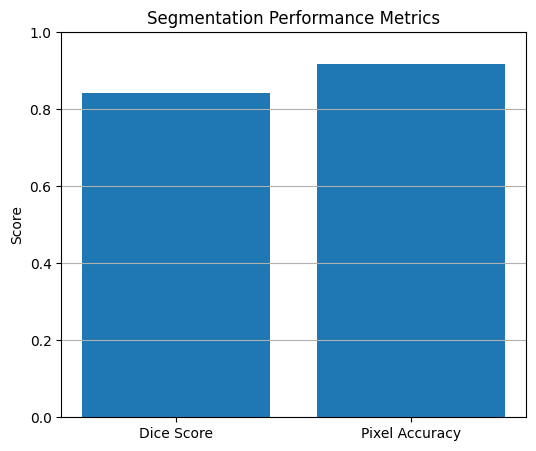

In [ ]:
metrics = {
    "Dice Score": final_dice,
    "Pixel Accuracy": final_acc
}

names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(6,5))

plt.bar(names, values)

plt.title("Segmentation Performance Metrics")

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis='y')

plt.show()


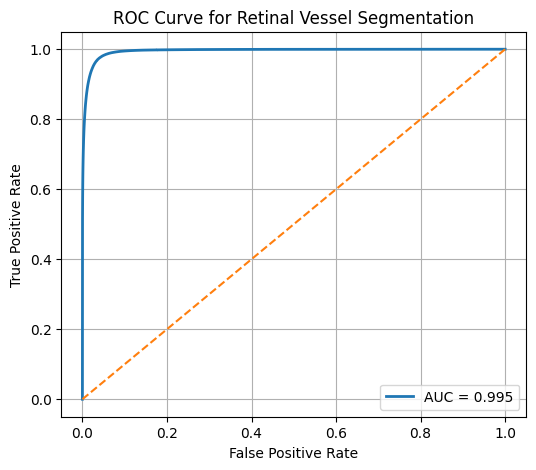

Final AUC Score: 0.9947497192154348


In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)

        preds = torch.sigmoid(model(images))

        all_preds.extend(preds.cpu().numpy().flatten())

        # Convert mask to binary
        binary_masks = (masks.numpy() > 0.5).astype(int)

        all_targets.extend(binary_masks.flatten())


all_preds = np.array(all_preds)
all_targets = np.array(all_targets)


fpr, tpr, thresholds = roc_curve(all_targets, all_preds)

roc_auc = auc(fpr, tpr)


plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve for Retinal Vessel Segmentation")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid()

plt.show()

print("Final AUC Score:", roc_auc)


In [ ]:
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
import numpy as np
import cv2

def extract_vascular_features(image, vessel_mask):

    vessel_mask = (vessel_mask > 0.5).astype(np.uint8)

    features = {}

    # Vessel density
    vessel_pixels = np.sum(vessel_mask)
    total_pixels = vessel_mask.size
    features["vessel_density"] = vessel_pixels / total_pixels

    # Skeletonize vessels
    skeleton = skeletonize(vessel_mask)

    labeled = label(skeleton)

    tortuosities = []

    for region in regionprops(labeled):

        coords = region.coords

        if len(coords) < 10:
            continue

        start = coords[0]
        end = coords[-1]

        straight_dist = np.linalg.norm(start - end)

        path_length = len(coords)

        if straight_dist > 0:
            tortuosities.append(path_length / straight_dist)

    features["mean_tortuosity"] = np.mean(tortuosities) if tortuosities else 0

    # Vessel width
    dist_transform = cv2.distanceTransform(
        vessel_mask.astype(np.uint8),
        cv2.DIST_L2,
        5
    )

    vessel_width = dist_transform[vessel_mask > 0] * 2

    features["mean_width"] = (
        np.mean(vessel_width) if len(vessel_width) > 0 else 0
    )

    # Intensity features (use green channel)
    green = image[:,:,1]

    vessel_intensity = green[vessel_mask > 0]

    features["mean_intensity"] = (
        np.mean(vessel_intensity) if len(vessel_intensity) > 0 else 0
    )

    features["std_intensity"] = (
        np.std(vessel_intensity) if len(vessel_intensity) > 0 else 0
    )

    return features


In [ ]:
import pandas as pd

model.eval()

all_features = []

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)

        preds = torch.sigmoid(model(images))

        for i in range(images.shape[0]):

            # Get original image
            img = images[i].cpu().numpy().transpose(1,2,0)

            # Undo normalization for feature extraction
            img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype(np.uint8)

            # Get predicted vessel mask
            vessel_mask = preds[i].cpu().numpy().squeeze()

            # Extract features
            features = extract_vascular_features(img, vessel_mask)

            all_features.append(features)


# Convert to DataFrame
df_features = pd.DataFrame(all_features)

print(df_features.head())

print("\nTotal samples:", len(df_features))


   vessel_density  mean_tortuosity  mean_width  mean_intensity  std_intensity
0        0.090221         1.434784    3.084985       86.510887      26.617872
1        0.091026         1.976362    2.895295      107.293060      20.812528
2        0.076424         1.897024    3.281587       95.426924      22.936409
3        0.079910         1.472508    3.117526       92.957609      23.129545
4        0.088120         1.449197    3.052474       92.262511      26.697436

Total samples: 20


In [ ]:
# Create synthetic labels based on tortuosity and vessel density

threshold_tortuosity = df_features["mean_tortuosity"].median()

threshold_density = df_features["vessel_density"].median()

df_features["label"] = (
    (df_features["mean_tortuosity"] > threshold_tortuosity) |
    (df_features["vessel_density"] > threshold_density)
).astype(int)


print(df_features.head())

print("\nLabel distribution:")
print(df_features["label"].value_counts())


   vessel_density  mean_tortuosity  mean_width  mean_intensity  std_intensity  \
0        0.090221         1.434784    3.084985       86.510887      26.617872   
1        0.091026         1.976362    2.895295      107.293060      20.812528   
2        0.076424         1.897024    3.281587       95.426924      22.936409   
3        0.079910         1.472508    3.117526       92.957609      23.129545   
4        0.088120         1.449197    3.052474       92.262511      26.697436   

   label  
0      1  
1      1  
2      1  
3      0  
4      0  

Label distribution:
label
1    13
0     7
Name: count, dtype: int64


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split features and labels

X = df_features.drop("label", axis=1)

y = df_features["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# Correct LightGBM settings for small dataset

clf = lgb.LGBMClassifier(

    n_estimators=200,

    learning_rate=0.05,

    num_leaves=5,

    min_child_samples=1,

    min_data_in_bin=1,

    max_depth=3
)


clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)


acc = accuracy_score(y_test, y_pred)

print("Fixed Classification Accuracy:", acc * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


[LightGBM] [Info] Number of positive: 9, number of negative: 5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 75
[LightGBM] [Info] Number of data points in the train set: 14, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.642857 -> initscore=0.587787
[LightGBM] [Info] Start training from score 0.587787
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

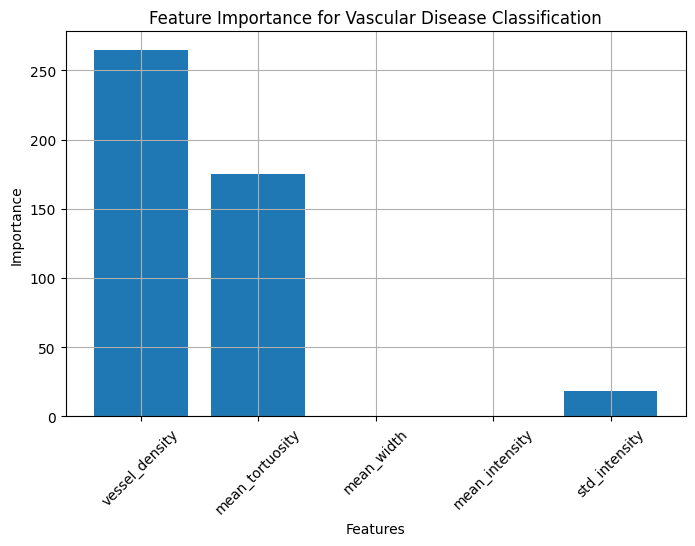

In [ ]:
import matplotlib.pyplot as plt

importance = clf.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,5))

plt.bar(feature_names, importance)

plt.title("Feature Importance for Vascular Disease Classification")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.grid()

plt.show()


In [ ]:
torch.save(model.state_dict(), "retinal_segmentation_model.pth")


In [ ]:
import joblib
joblib.dump(clf, "vascular_classifier.pkl")


['vascular_classifier.pkl']

In [ ]:
df_features.to_csv("vascular_features.csv", index=False)


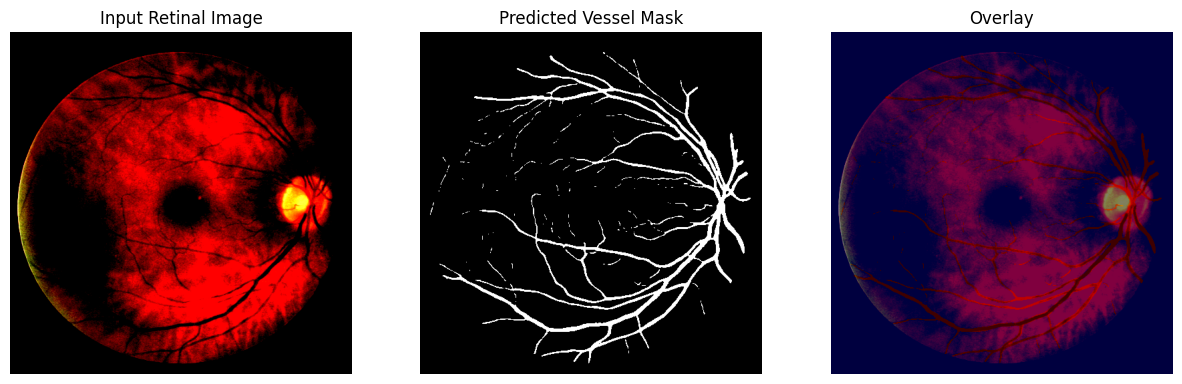

In [ ]:
model.eval()

# Get one sample image
images, masks = next(iter(train_loader))

input_img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    pred = torch.sigmoid(model(input_img))

# Convert to numpy
img = images[0].cpu().numpy().transpose(1,2,0)

pred_mask = pred[0].cpu().numpy().squeeze()

# Threshold mask
pred_mask_binary = (pred_mask > 0.65).astype(np.uint8)


# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Retinal Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Vessel Mask")
plt.imshow(pred_mask_binary, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img)
plt.imshow(pred_mask_binary, cmap="jet", alpha=0.5)
plt.axis("off")

plt.show()


In [ ]:
dice_scores = []

model.eval()

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        pred_bin = (torch.sigmoid(preds) > 0.65).float()

        intersection = (pred_bin * masks).sum()

        dice = (2 * intersection) / (pred_bin.sum() + masks.sum() + 1e-8)

        dice_scores.append(dice.item())

print("Average Dice Score:", sum(dice_scores)/len(dice_scores))


Average Dice Score: 0.8437251389026642


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving download.jpg to download.jpg


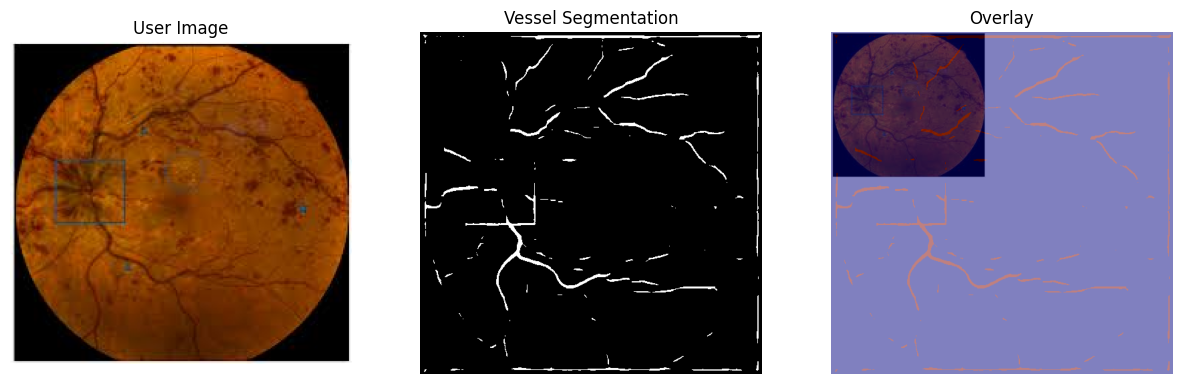

Result: Normal Vascular Structure


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

original = img.copy()

# Apply CLAHE preprocessing
img = apply_clahe_rgb(img)

# Resize
img_resized = cv2.resize(img, (512,512))

# Normalize
img_norm = img_resized / 255.0

# Convert to tensor
img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)

# Segmentation
model.eval()

with torch.no_grad():
    pred = torch.sigmoid(model(img_tensor))

pred_mask = pred[0].cpu().numpy().squeeze()

pred_binary = (pred_mask > 0.65).astype(np.uint8)

# Feature extraction
features = extract_vascular_features(img_resized, pred_binary)

# Convert to dataframe
import pandas as pd
features_df = pd.DataFrame([features])

# Classification
prediction = clf.predict(features_df)[0]

# Show result
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("User Image")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Vessel Segmentation")
plt.imshow(pred_binary, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(original)
plt.imshow(pred_binary, cmap="jet", alpha=0.5)
plt.axis("off")

plt.show()

# Print classification result
if prediction == 1:
    print("Result: Vascular Abnormality Detected")
else:
    print("Result: Normal Vascular Structure")


In [ ]:
def classify_vascular_health(features):

    density = features["vessel_density"]
    tortuosity = features["mean_tortuosity"]
    width = features["mean_width"]

    # Risk scoring system
    score = 0

    if density > 0.09:
        score += 1

    if tortuosity > 1.7:
        score += 1

    if width > 3.2:
        score += 1

    # Classification
    if score == 0:
        return "Low Risk"
    elif score == 1:
        return "Medium Risk"
    else:
        return "High Risk"


In [ ]:
# Extract features
features = extract_vascular_features(img_resized, pred_binary)

# Classify vascular health
health_status = classify_vascular_health(features)

print("Vascular Health Status:", health_status)


Vascular Health Status: Low Risk


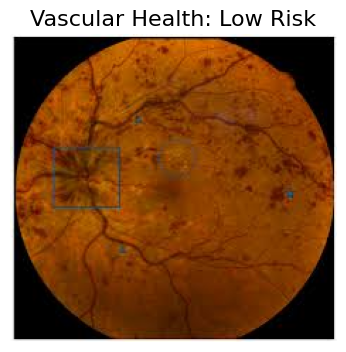

In [ ]:
plt.figure(figsize=(6,4))

plt.imshow(original)
plt.title(f"Vascular Health: {health_status}", fontsize=16)

plt.axis("off")

plt.show()


In [ ]:
from google.colab import files
files.download("retinal_segmentation_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>